# Linear Regression

Linear Regression Equation in Vector form: $$ \hat{y} = h_{\theta}(\textbf{x}) = \boldsymbol{\theta} \cdot \textbf{x} $$ 

Mean Squared Error cost function for Linear Regression: $$ MSE(\textbf{X}, h_{\theta}) = \frac{1}{m} \sum_{i=1}^{m} (\boldsymbol{\theta}^{T}\textbf{x}^{(i)} - y^{(i)})^2 $$

Normal Equation: $$ \hat{\boldsymbol{\theta}} = (\textbf{X}^{T}\textbf{X})^{-1} \   \textbf{X}^T \  y $$ 

In [1]:
import numpy as np

X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

In [5]:
X_b = np.c_[np.ones((100, 1)), X]
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y) # Normal Equation

In [6]:
theta_best

array([[4.18938719],
       [2.79777518]])

In [7]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new] # x_0 = 1 for all cases
y_predict = X_new_b.dot(theta_best)
y_predict

array([[4.18938719],
       [9.78493754]])

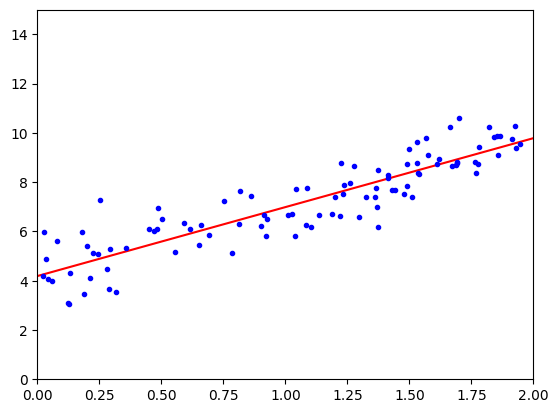

In [9]:
import matplotlib.pyplot as plt

plt.plot(X_new, y_predict, "r-")
plt.plot(X, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

## Using Scikit-Learn

In [10]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.18938719]), array([[2.79777518]]))

In [11]:
lin_reg.predict(X_new)

array([[4.18938719],
       [9.78493754]])

### Using Pseudoinverse

In [14]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6) # Uses pseudoinverse of X
theta_best_svd

array([[4.18938719],
       [2.79777518]])

In [15]:
np.linalg.pinv(X_b).dot(y) # Using pinv (pseudoinvers) directly

array([[4.18938719],
       [2.79777518]])

Pseudoinverse is computed using _Singular Value Decomposition_ (SVD). 

Both Normal Equation and SVD approach get slow as number of features increase. Now we'll look at a different way which is better suited for large number of features. 

# Gradient Descent

- Generic optimization algorithm 
- Finds optimal solutions for a wide range of problems
- General idea: tweak parameters iteratively to minimize a cost function
- Measures local gradient of error function with respect to parameter vector $\theta$ and goes in direction of descending gradient.
- Learning rate: a parameter which determines the size of steps.\
- Feature scaling should be done when using Gradient Descent.

## Batch Gradient Descent
Formula: 
$$ \nabla J(\theta) = \begin{bmatrix}
\frac{\partial}{\partial \theta_0} J(\theta) \\
\frac{\partial}{\partial \theta_1} J(\theta) \\
\vdots \\
\frac{\partial}{\partial \theta_n} J(\theta)
\end{bmatrix} = \frac{2}{m} \mathbf{X}^T (\mathbf{X}\cdot\boldsymbol{\theta} - \mathbf{y}) $$ 

- This formula involves calculations over full training set ($ \textbf{X} $) at each step. This is why it's known as Batch Gradient Descent.
- It is very slow on large training sets.

In [16]:
eta = 0.1 # learning rate
n_iterations = 1000 
m = 100 

theta = np.random.randn(2, 1) # random initialization

for iteration in range(n_iterations): 
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

In [17]:
theta

array([[4.18938719],
       [2.79777518]])

If learning rate is less, the algorithm would take a long amount of time to reach the solution. If it's too high however, then the algorithm would diverge and keep going further away at each step. If it's "just right", it will converge to a solution in a small number of steps. 

If the number of iterations is too low, the algorithm wouldn't reach the solution when it terminates. If it's too high, it will waste time while model parameters don't change. 

We set a large number of iterations, but interrupt the algorithm when gradient vector becomes tiny (smaller than tolerance $\epsilon$)

## Stochastic Gradient Descent
- Batch Gradient descent uses the whole training set at every step, which makes it very slow.
- Stochastic Gradient Descent chooses a random instance in the training step at every step and computes the gradients based only on that instance.
- Stochastic Gradient Descent is much less regular than Batch Gradient Descent, going up and down, and only decreasing on average.
- Eventually, it gets close to minimum, but it continues to bounce around and therefore at the end of the algorithm, the parameters are good but not optional.
- It can help in cases where cost function is irregular and helps the algorithm to jump out of local minima, and therefore SGD has a better chance of finding global minima than BGD does.
- This is often solved by gradually reducing the learning rate.
- The function that determines the learning rate at each step is known as _learning schedule_.
- If learning rate is reduced too quickly, it can get stuck in a local minimum or frozen halfway to minimum. If it is reduced too slowly, it might jump around minimum for a long time and end up with a suboptimal solution if training is stopped too early.

In [19]:
n_epochs = 50 
t0, t1 = 5, 50 # learning schedule hyperparameters

In [20]:
def learning_schedule(t):
    return t0 / (t + t1) 

theta = np.random.randn(2, 1)

for epoch in range(n_epochs):
    for i in range(m): 
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi) 
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients

Each round is called _epoch_
_m_ iterations is convention

In [21]:
theta

array([[4.15813431],
       [2.85408014]])

### Using Scikit-Learn

In [22]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.1)
sgd_reg.fit(X, y.ravel())

,loss,'squared_error'
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [23]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.19602217]), array([2.81967843]))

## Mini-batch Gradient Descent

- Instead of computing the gradients based on the full training set or just one instance, Mini-batch GD computers the gradients on small random sets of instances called mini-batches.
- The main advantage this has over SGD is that you can get a performance boosts from hardware optimization of matrix operations (with GPUs).
- It's less erratic than SGD and hence ends up a bit closer to the minimum than SGD, but it may be harder to escape local minima.